<a href="https://colab.research.google.com/github/Srinu-29/Early-stroke-detection-using-ML/blob/main/Stroke_prediction_using__ML_Algorithms.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# Stroke Detection ML Project
# Team - 13

# 1. Importing libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier



In [ ]:
# 2. Load the dataset
# Replace with your dataset path
# Example dataset: "healthcare-dataset-stroke-data.csv" from Kaggle
data = pd.read_csv("healthcare-dataset-stroke-data.csv")

print("Dataset Shape:", data.shape)
print(data.head())


Dataset Shape: (5110, 12)
      id  gender   age  hypertension  heart_disease ever_married  \
0   9046    Male  67.0             0              1          Yes   
1  51676  Female  61.0             0              0          Yes   
2  31112    Male  80.0             0              1          Yes   
3  60182  Female  49.0             0              0          Yes   
4   1665  Female  79.0             1              0          Yes   

       work_type Residence_type  avg_glucose_level   bmi   smoking_status  \
0        Private          Urban             228.69  36.6  formerly smoked   
1  Self-employed          Rural             202.21   NaN     never smoked   
2        Private          Rural             105.92  32.5     never smoked   
3        Private          Urban             171.23  34.4           smokes   
4  Self-employed          Rural             174.12  24.0     never smoked   

   stroke  
0       1  
1       1  
2       1  
3       1  
4       1  


In [ ]:
# 3. Preprocessing
# Drop irrelevant columns if present (like id)
if "id" in data.columns:
    data.drop("id", axis=1, inplace=True)

# Handle categorical features (example: 'gender', 'smoking_status')
data = pd.get_dummies(data, drop_first=True)

# Fill missing values (example: bmi has nulls in Kaggle dataset)
data.fillna(data.mean(numeric_only=True), inplace=True)

# Separate features and target
X = data.drop("stroke", axis=1)
y = data["stroke"]
print(X)
print("Y=",y)

# Scale features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

       age  hypertension  heart_disease  avg_glucose_level        bmi  \
0     67.0             0              1             228.69  36.600000   
1     61.0             0              0             202.21  28.893237   
2     80.0             0              1             105.92  32.500000   
3     49.0             0              0             171.23  34.400000   
4     79.0             1              0             174.12  24.000000   
...    ...           ...            ...                ...        ...   
5105  80.0             1              0              83.75  28.893237   
5106  81.0             0              0             125.20  40.000000   
5107  35.0             0              0              82.99  30.600000   
5108  51.0             0              0             166.29  25.600000   
5109  44.0             0              0              85.28  26.200000   

      gender_Male  gender_Other  ever_married_Yes  work_type_Never_worked  \
0            True         False              T

In [ ]:
# 4. Train-Test Split
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42, stratify=y
)


Logistic Regression Accuracy: 0.9521
              precision    recall  f1-score   support

           0       0.95      1.00      0.98       972
           1       1.00      0.02      0.04        50

    accuracy                           0.95      1022
   macro avg       0.98      0.51      0.51      1022
weighted avg       0.95      0.95      0.93      1022



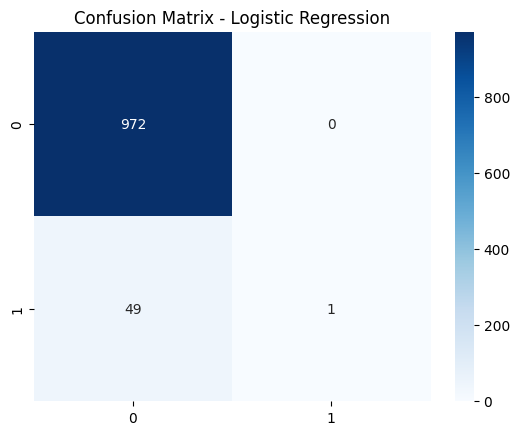


KNN Accuracy: 0.9491
              precision    recall  f1-score   support

           0       0.95      1.00      0.97       972
           1       0.25      0.02      0.04        50

    accuracy                           0.95      1022
   macro avg       0.60      0.51      0.51      1022
weighted avg       0.92      0.95      0.93      1022



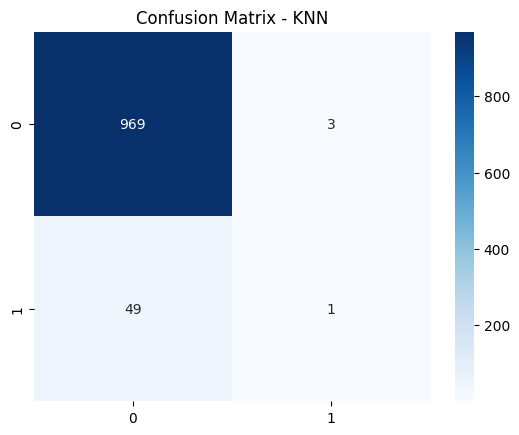


SVM Accuracy: 0.9511
              precision    recall  f1-score   support

           0       0.95      1.00      0.97       972
           1       0.00      0.00      0.00        50

    accuracy                           0.95      1022
   macro avg       0.48      0.50      0.49      1022
weighted avg       0.90      0.95      0.93      1022



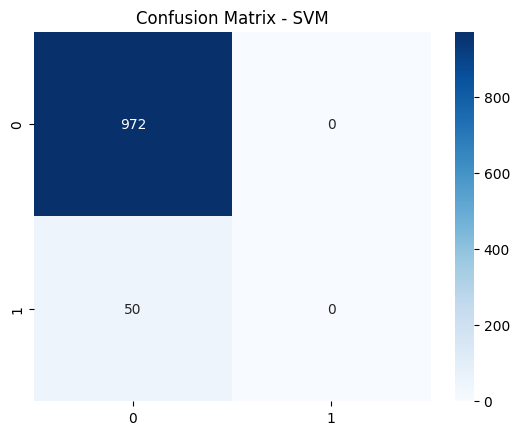


Decision Tree Accuracy: 0.9119
              precision    recall  f1-score   support

           0       0.96      0.95      0.95       972
           1       0.17      0.20      0.18        50

    accuracy                           0.91      1022
   macro avg       0.56      0.57      0.57      1022
weighted avg       0.92      0.91      0.92      1022



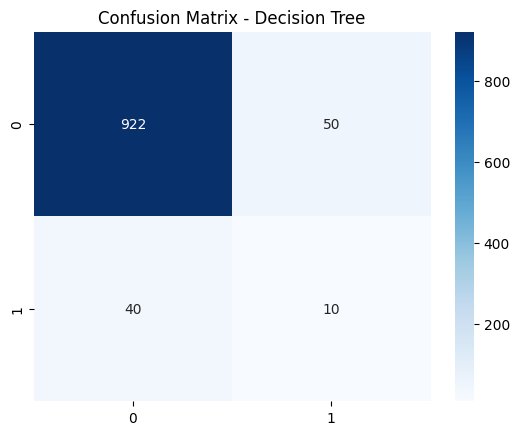


Random Forest Accuracy: 0.9501
              precision    recall  f1-score   support

           0       0.95      1.00      0.97       972
           1       0.33      0.02      0.04        50

    accuracy                           0.95      1022
   macro avg       0.64      0.51      0.51      1022
weighted avg       0.92      0.95      0.93      1022



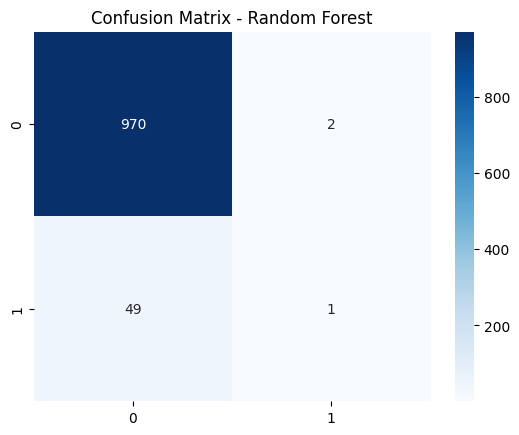

In [ ]:
# 5. Build Models and Evaluate

models = {
    "Logistic Regression": LogisticRegression(max_iter=1000),
    "KNN": KNeighborsClassifier(),
    "SVM": SVC(),
    "Decision Tree": DecisionTreeClassifier(),
    "Random Forest": RandomForestClassifier()
}

results = {}

for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    acc = accuracy_score(y_test, y_pred)
    results[name] = acc
    print(f"\n{name} Accuracy: {acc:.4f}")
    # Set zero_division=0 to suppress the warning
    print(classification_report(y_test, y_pred, zero_division=0))
    sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt="d", cmap="Blues")
    plt.title(f"Confusion Matrix - {name}")
    plt.show()

Distribution of 'stroke' column:
stroke
0    4861
1     249
Name: count, dtype: int64


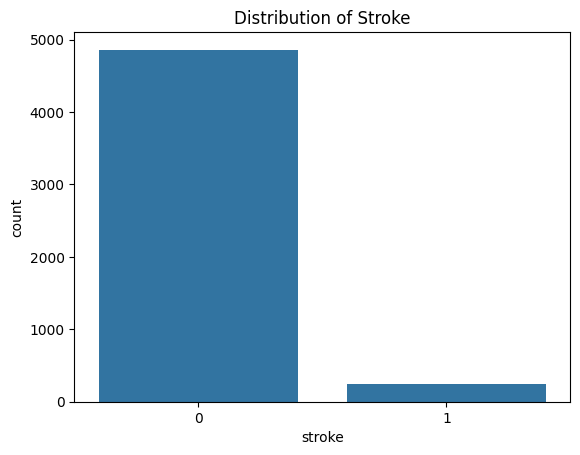

In [ ]:
print("Distribution of 'stroke' column:")
print(data['stroke'].value_counts())

sns.countplot(x='stroke', data=data)
plt.title('Distribution of Stroke')
plt.show()


Model Comparison:
                  Model  Accuracy
0  Logistic Regression  0.952055
1                  KNN  0.949119
2                  SVM  0.951076
3        Decision Tree  0.905088
4        Random Forest  0.949119


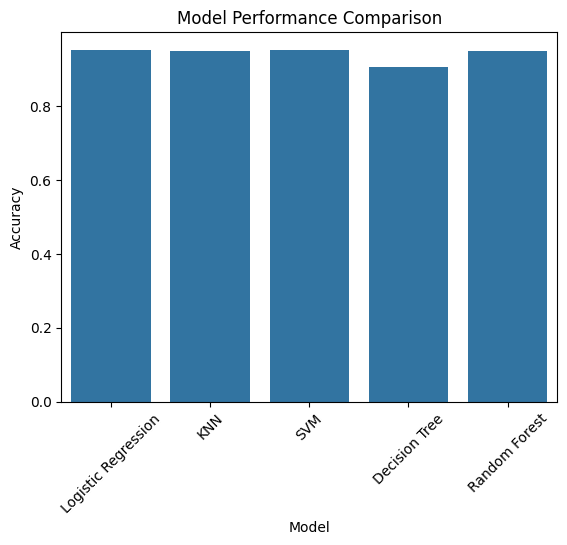

In [ ]:
results_df = pd.DataFrame(list(results.items()), columns=["Model", "Accuracy"])
print("\nModel Comparison:\n", results_df)

sns.barplot(x="Model", y="Accuracy", data=results_df)
plt.xticks(rotation=45)
plt.title("Model Performance Comparison")
plt.show()